# Marketing Engagement and Opportunity Prediction

This project analyzes webinar engagement data to predict whether a user converts into a business opportunity.

The notebook walks through a full machine learning workflow including data cleaning, feature engineering, modeling, and evaluation. Special attention is given to class imbalance and model performance beyond simple accuracy.

Key goals:
- Understand engagement behavior
- Identify drivers of conversion
- Build and evaluate classification models

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.utils import resample

## Load Dataset

In [2]:
data = pd.read_csv('market_analysis.csv')
data.head()

,Total number of Zoom webinar registrations,Total number of Zoom webinars attended,Average Zoom webinar attendance duration,Number of Zoom webinar durations >50%,Survey response: Speak with ProfDev?,State/Region,Country/Region,Opportunity
0,8.0,6.0,55%,5.0,No,Massachusetts,United States,0
1,4.0,1.0,50%,1.0,NaN,Virginia,United States,0
2,7.0,3.0,57%,1.0,NaN,NaN,NaN,0
3,27.0,15.0,45%,8.0,No,California,United States,0
4,5.0,4.0,59%,3.0,No,Texas,United States,0


## Data Overview

In [3]:
data.info()
data.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1691 entries, 0 to 1690
Data columns (total 8 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Total number of Zoom webinar registrations  1679 non-null   float64
 1   Total number of Zoom webinars attended      1679 non-null   float64
 2   Average Zoom webinar attendance duration    1679 non-null   object 
 3   Number of Zoom webinar durations >50%       1547 non-null   float64
 4   Survey response: Speak with ProfDev?        782 non-null    object 
 5   State/Region                                1331 non-null   object 
 6   Country/Region                              1344 non-null   object 
 7   Opportunity                                 1691 non-null   int64  
dtypes: float64(3), int64(1), object(4)
memory usage: 105.8+ KB


,count,mean,std,min,25%,50%,75%,max
Total number of Zoom webinar registrations,1679.0,9.379392,8.540841,0.0,4.0,7.0,12.0,57.0
Total number of Zoom webinars attended,1679.0,5.060155,5.852524,0.0,1.0,3.0,6.0,46.0
Number of Zoom webinar durations >50%,1547.0,3.390433,3.629527,1.0,1.0,2.0,4.0,27.0
Opportunity,1691.0,0.074512,0.262680,0.0,0.0,0.0,0.0,1.0


## Data Cleaning

Rename columns and convert percentage-based fields into numeric values.

In [4]:
rename_map = {
    'Total number of Zoom webinar registrations': 'registrations',
    'Total number of Zoom webinars attended': 'attended',
    'Average Zoom webinar attendance duration': 'attendance_duration',
    'Number of Zoom webinar durations >50%': 'duration_>50',
    'Survey response: Speak with ProfDev?': 'survey'
}

data = data.rename(columns=rename_map)
data['attendance_duration'] = data['attendance_duration'].str.rstrip('%').astype(float) / 100
data.head()

,registrations,attended,attendance_duration,duration_>50,survey,State/Region,Country/Region,Opportunity
0,8.0,6.0,0.55,5.0,No,Massachusetts,United States,0
1,4.0,1.0,0.50,1.0,NaN,Virginia,United States,0
2,7.0,3.0,0.57,1.0,NaN,NaN,NaN,0
3,27.0,15.0,0.45,8.0,No,California,United States,0
4,5.0,4.0,0.59,3.0,No,Texas,United States,0


## Handling Missing Values

In [5]:
float_cols = ['registrations', 'attended', 'attendance_duration', 'duration_>50']

data[float_cols] = data[float_cols].fillna(data[float_cols].median())
data['survey'] = data['survey'].fillna('No')
data['State/Region'] = data['State/Region'].fillna('Unknown')
data['Country/Region'] = data['Country/Region'].fillna('Unknown')

## Encode Categorical Features

In [6]:
data = pd.get_dummies(data, columns=['State/Region', 'Country/Region'], drop_first=True, dtype=int)

## Exploratory Data Analysis

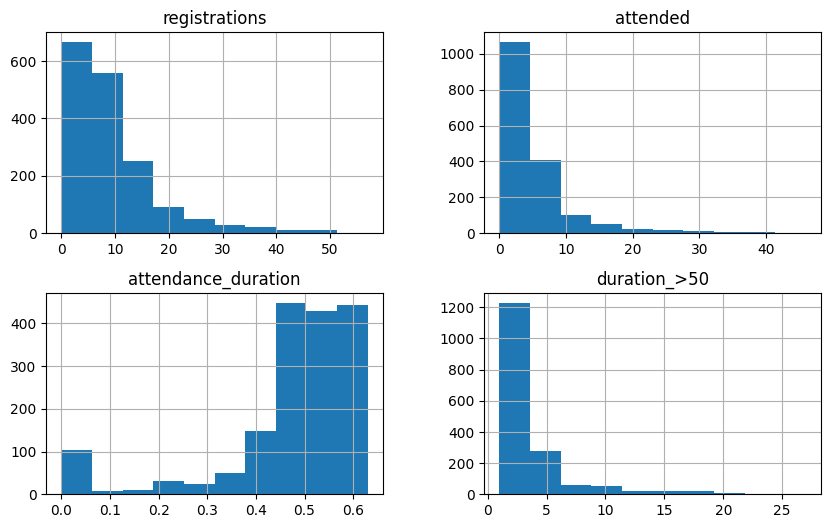

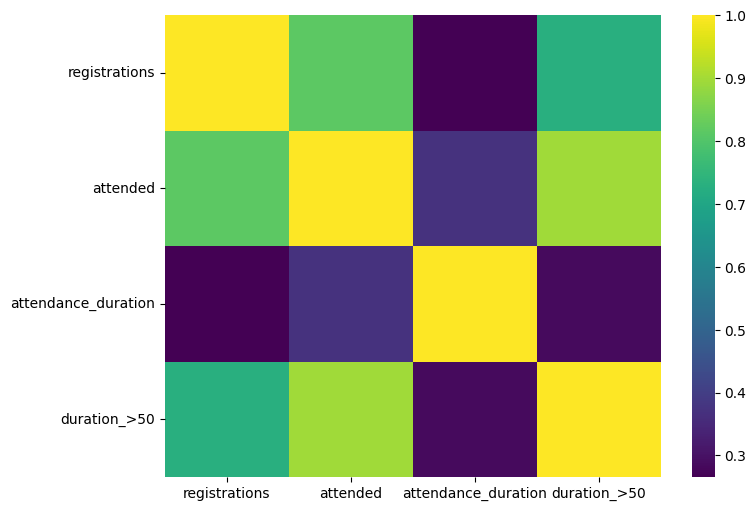

In [7]:
data[float_cols].hist(bins=10, figsize=(10,6))
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(data[float_cols].corr(), cmap='viridis')
plt.show()

## Prepare Target Variable

Convert target into binary format and encode survey responses.

In [8]:
data['Opportunity'] = data['Opportunity'].replace({0: 'no', 1: 'yes'})
data['survey'] = data['survey'].replace({'No': 0, 'Yes': 1})

/var/folders/80/q5zbz2x55cv8zcxjj9h4bvv80000gn/T/ipykernel_35104/1501944734.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['survey'] = data['survey'].replace({'No': 0, 'Yes': 1})


## Handle Class Imbalance

The dataset is imbalanced, which can lead to misleadingly high accuracy but poor recall for the minority class.

We use upsampling to balance the classes.

In [9]:
majority = data[data.Opportunity == 'no']
minority = data[data.Opportunity == 'yes']

minority_upsampled = resample(minority,
                             replace=True,
                             n_samples=len(majority),
                             random_state=42)

data_balanced = pd.concat([majority, minority_upsampled])
data_balanced['Opportunity'].value_counts()

Opportunity
no     1565
yes    1565
Name: count, dtype: int64

## Train-Test Split and Scaling

In [10]:
X = data_balanced.drop(columns=['Opportunity'])
y = data_balanced['Opportunity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

scaler = MinMaxScaler()
X_train_n = scaler.fit_transform(X_train)
X_test_n = scaler.transform(X_test)

## Logistic Regression Model

In [11]:
log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_n, y_train)

print('Training Accuracy:', log_reg.score(X_train_n, y_train))
print('Test Accuracy:', log_reg.score(X_test_n, y_test))

Training Accuracy: 0.6732085805568234
Test Accuracy: 0.6070287539936102


## Model Evaluation

In [12]:
y_pred = log_reg.predict(X_test_n)
y_probs = log_reg.predict_proba(X_test_n)[:,1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[286 200]
 [169 284]]
              precision    recall  f1-score   support

          no       0.63      0.59      0.61       486
         yes       0.59      0.63      0.61       453

    accuracy                           0.61       939
   macro avg       0.61      0.61      0.61       939
weighted avg       0.61      0.61      0.61       939



## ROC Curve

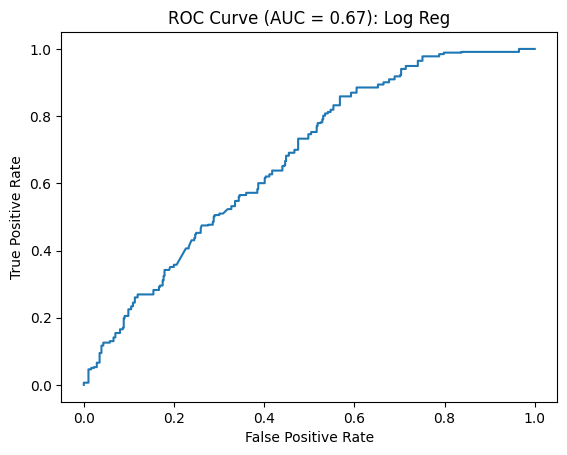

In [13]:
fpr, tpr, _ = roc_curve((y_test=='yes').astype(int), y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {roc_auc:.2f}): Log Reg')
plt.show()

## Precision-Recall Curve

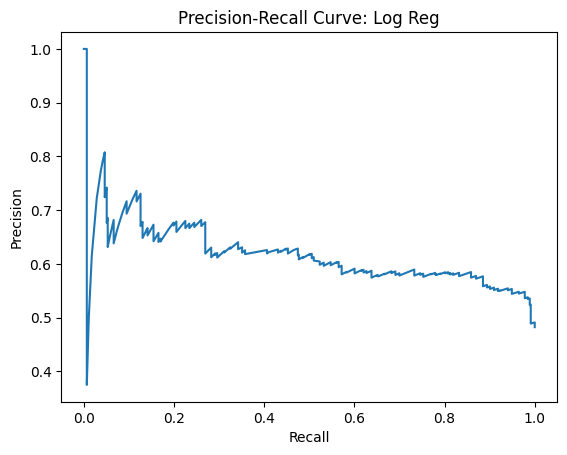

In [14]:
precision, recall, _ = precision_recall_curve((y_test=='yes').astype(int), y_probs)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Log Reg')
plt.show()

## Decision Tree Classifier

In [15]:
tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_train_n, y_train)

print('Training Accuracy:', tree_clf.score(X_train_n, y_train))
print('Test Accuracy:', tree_clf.score(X_test_n, y_test))

Training Accuracy: 0.9780921953445915
Test Accuracy: 0.919062832800852


## Model Evaluation

In [16]:
y_predict = tree_clf.predict(X_test_n)
y_proba = tree_clf.predict_proba(X_test_n)[:,1]

print(confusion_matrix(y_test, y_predict))
print(classification_report(y_test, y_predict))

[[410  76]
 [  0 453]]
              precision    recall  f1-score   support

          no       1.00      0.84      0.92       486
         yes       0.86      1.00      0.92       453

    accuracy                           0.92       939
   macro avg       0.93      0.92      0.92       939
weighted avg       0.93      0.92      0.92       939



## ROC Curve

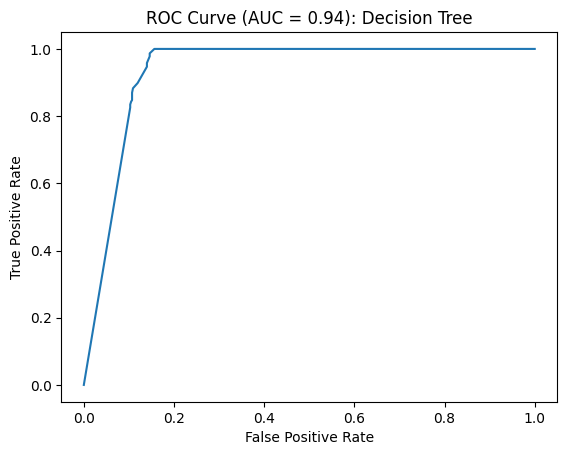

In [17]:
false_pr, true_pr, _ = roc_curve((y_test=='yes').astype(int), y_proba)
roc_auc_tree = auc(false_pr, true_pr)

plt.plot(false_pr, true_pr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {roc_auc_tree:.2f}): Decision Tree')
plt.show()

## Precision-Recall Curve

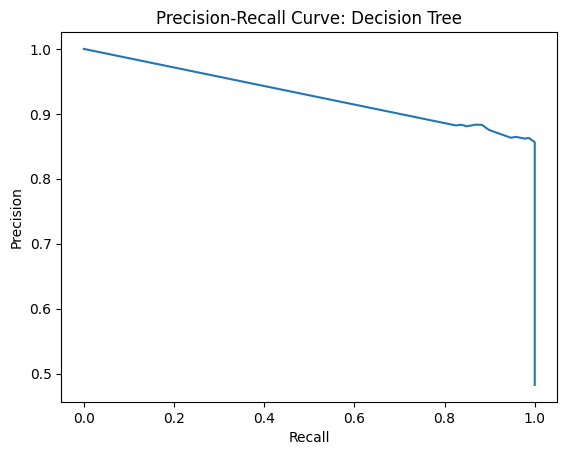

In [18]:
prec, rec, _ = precision_recall_curve((y_test=='yes').astype(int), y_proba)

plt.plot(rec, prec)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Decision Tree')
plt.show()

## Random Forest Classifier

In [20]:
forest_clf = RandomForestClassifier()
forest_clf.fit(X_train_n, y_train)

print('Training Accuracy:', forest_clf.score(X_train_n, y_train))
print('Test Accuracy:', forest_clf.score(X_test_n, y_test))

Training Accuracy: 0.9780921953445915
Test Accuracy: 0.9552715654952076


## Model Evaluation

In [21]:
y_p = forest_clf.predict(X_test_n)
y_probab = forest_clf.predict_proba(X_test_n)[:,1]

print(confusion_matrix(y_test, y_p))
print(classification_report(y_test, y_p))

[[444  42]
 [  0 453]]
              precision    recall  f1-score   support

          no       1.00      0.91      0.95       486
         yes       0.92      1.00      0.96       453

    accuracy                           0.96       939
   macro avg       0.96      0.96      0.96       939
weighted avg       0.96      0.96      0.96       939



## ROC Curve

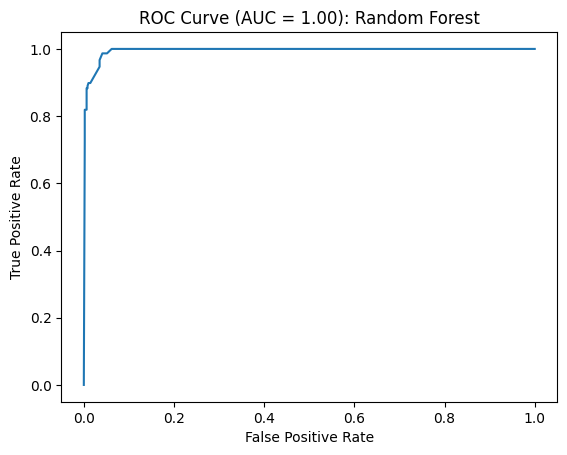

In [22]:
false_p_r, true_p_r, _ = roc_curve((y_test=='yes').astype(int), y_probab)
roc_auc_tree = auc(false_p_r, true_p_r)

plt.plot(false_p_r, true_p_r)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {roc_auc_tree:.2f}): Random Forest')
plt.show()

## Precision-Recall Curve

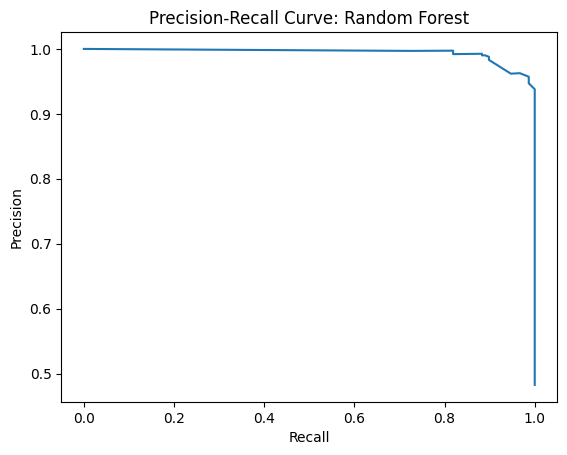

In [23]:
pr, re, _ = precision_recall_curve((y_test=='yes').astype(int), y_probab)

plt.plot(re, pr)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Random Forest')
plt.show()